# Organic Chemical Compound Boiling Points Prediction

In this project, I developed a ML model that can accurately predict the boiling points of organic chemical compounds from their chemical properties. The workflow includes *Data Collection*,*Data pre-processing and clearning*, *Model selection and training*, and *Model evaluation*. Five classic machine learning architectures, including **Linear Regression**, **Random Forest**, **XGBoost**, **Neural Network**, and **Support Vector Regression**, were trained and evaluated.
## Summary of Results
Since the five architectures show comparable validation performance (confirmed formally further below via a split-sensitivity analysis), a simple-averaging **ensemble of Ridge, XGBoost, and a Neural Network** is used instead of a single "champion" model. To further improve model performance, more data (particularly more data with large polar area and/or rotbonds) should be collected to re-train the model.



# Data Collection
 

1. Chemical structure data is widely accessible online and I collected a large dataset of chemical compounds and their chemical properties from PubChem, a trusted and reputable chemical database. The file "compound_property_from_PubChem.csv" is downloaded from PubChem (https://pubchem.ncbi.nlm.nih.gov/). It contains 324,628 records. I mannually deleted some columns  of the raw data file downloaded, mainly string type columns, to reduce the file size.
2. High-quality physical property data is less commonly available through public APIs. I sourced a smaller but well-documented dataset from a published academic journal article. The file "compound_boiling_points_from_literature.xlsx" is accessed from a literature (https://pubs.acs.org/doi/10.1021/acs.jchemed.3c01040). It contains 1748 records.
    

In [1]:
# Import libraries and packages
import os
import sys
sys.path.insert(0, "src")

import warnings
# Benign false-positive from macOS Accelerate BLAS during matmul in
# cross-validation scoring; verified it does not produce NaN results.
# Set both in-process and via PYTHONWARNINGS so it also reaches the
# joblib worker processes spawned by GridSearchCV(n_jobs=-1).
warnings.filterwarnings("ignore", message=".*encountered in matmul.*")
os.environ["PYTHONWARNINGS"] = "ignore::RuntimeWarning"

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import learning_curve, cross_val_score

from boiling_point import data, features, preprocessing, models, viz, evaluation
from boiling_point import ensemble as ensemble_module


# Read data 

In [2]:
# Load the data on compound boiling points
df1 = data.load_literature_data("compound_boiling_points_from_literature.xlsx")
print(df1.head())
print()
print(df1.shape)
print()
print(df1.info())
print()
# check is there are null values
print(df1.isna().sum())


          cmpdname  boiling_point_kelvin
0  Ethylene Glycol                470.65
1   2,3-Butanediol                455.15
2        1-Butanol                390.75
3          Methane                111.65
4           Octane                398.77

(1748, 2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1748 entries, 0 to 1747
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cmpdname              1748 non-null   object 
 1   boiling_point_kelvin  1748 non-null   float64
dtypes: float64(1), object(1)
memory usage: 27.4+ KB
None

cmpdname                0
boiling_point_kelvin    0
dtype: int64


In [3]:
# Load the compound physicochemical property file (already narrowed to the
# columns useful for modeling; see boiling_point.data.PUBCHEM_COLUMNS)
df2 = data.load_pubchem_data("compound_property_from_PubChem.csv")
print(df2.columns)
print(df2.shape)


Index(['cmpdname', 'mw', 'mf', 'polararea', 'hbonddonor', 'hbondacc',
       'rotbonds', 'heavycnt', 'isosmiles', 'charge'],
      dtype='object')
(324628, 10)


# Data Pre-processing and Exploratory Data Analysis
1. Get information of the dataset
2. Feature engineering for modelling


In [4]:
# merge the dataset from PubChem (phychemical property data) with boiling point data
df = data.merge_datasets(df1, df2)
df.head()


,cmpdname,boiling_point_kelvin,mw,mf,polararea,hbonddonor,hbondacc,rotbonds,heavycnt,isosmiles,charge
0,Ethylene Glycol,470.65,62.070,C2H6O2,40.5,2,2,1,4,C(CO)O,0
1,"2,3-Butanediol",455.15,90.120,C4H10O2,40.5,2,2,1,6,CC(C(C)O)O,0
2,1-Butanol,390.75,74.120,C4H10O,20.2,1,1,2,5,CCCCO,0
3,Methane,111.65,16.043,CH4,0.0,0,0,0,1,C,0
4,Octane,398.77,114.230,C8H18,0.0,0,0,5,8,CCCCCCCC,0


In [5]:
# check basic information about the data
print (df.shape)
print()
print((df.isna().sum()))
print()
df.info()


(1588, 11)

cmpdname                0
boiling_point_kelvin    0
mw                      0
mf                      0
polararea               0
hbonddonor              0
hbondacc                0
rotbonds                0
heavycnt                0
isosmiles               0
charge                  0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1588 entries, 0 to 1587
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cmpdname              1588 non-null   object 
 1   boiling_point_kelvin  1588 non-null   float64
 2   mw                    1588 non-null   float64
 3   mf                    1588 non-null   object 
 4   polararea             1588 non-null   float64
 5   hbonddonor            1588 non-null   int64  
 6   hbondacc              1588 non-null   int64  
 7   rotbonds              1588 non-null   int64  
 8   heavycnt              1588 non-null   int64  
 9   isosmiles      

In [6]:
df.head()


,cmpdname,boiling_point_kelvin,mw,mf,polararea,hbonddonor,hbondacc,rotbonds,heavycnt,isosmiles,charge
0,Ethylene Glycol,470.65,62.070,C2H6O2,40.5,2,2,1,4,C(CO)O,0
1,"2,3-Butanediol",455.15,90.120,C4H10O2,40.5,2,2,1,6,CC(C(C)O)O,0
2,1-Butanol,390.75,74.120,C4H10O,20.2,1,1,2,5,CCCCO,0
3,Methane,111.65,16.043,CH4,0.0,0,0,0,1,C,0
4,Octane,398.77,114.230,C8H18,0.0,0,0,5,8,CCCCCCCC,0


In [7]:
# Feature engineering for features that are potentially useful for predicting boiling points (background knowledge)
df = features.add_smiles_features(df)


In [8]:
df.head()


,cmpdname,boiling_point_kelvin,mw,mf,polararea,hbonddonor,hbondacc,rotbonds,heavycnt,isosmiles,charge,C_cnt,O_cnt,N_cnt,F_cnt,side_chain_cnt,double_bond_cnt,triple_bond_cnt
0,Ethylene Glycol,470.65,62.070,C2H6O2,40.5,2,2,1,4,C(CO)O,0,2,2,0,0,1,0,0
1,"2,3-Butanediol",455.15,90.120,C4H10O2,40.5,2,2,1,6,CC(C(C)O)O,0,4,2,0,0,2,0,0
2,1-Butanol,390.75,74.120,C4H10O,20.2,1,1,2,5,CCCCO,0,4,1,0,0,0,0,0
3,Methane,111.65,16.043,CH4,0.0,0,0,0,1,C,0,1,0,0,0,0,0,0
4,Octane,398.77,114.230,C8H18,0.0,0,0,5,8,CCCCCCCC,0,8,0,0,0,0,0,0


In [9]:
# Get basic statistical information of the dataset
df.describe()


,boiling_point_kelvin,mw,polararea,hbonddonor,hbondacc,rotbonds,heavycnt,charge,C_cnt,O_cnt,N_cnt,F_cnt,side_chain_cnt,double_bond_cnt,triple_bond_cnt
count,1588.000000,1588.000000,1588.000000,1588.000000,1588.000000,1588.000000,1588.000000,1588.0,1588.000000,1588.000000,1588.000000,1588.0,1588.000000,1588.000000,1588.000000
mean,476.406926,160.281980,10.991120,0.511965,0.617128,6.375315,11.290932,0.0,10.672544,0.488665,0.128463,0.0,1.583123,0.397355,0.098237
std,126.277949,84.086372,17.074557,0.794107,0.960864,6.185757,5.979781,0.0,6.105238,0.917792,0.454477,0.0,1.389044,0.797076,0.341127
min,111.650000,16.043000,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,1.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
25%,403.900000,112.210000,0.000000,0.000000,0.000000,3.000000,8.000000,0.0,7.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
50%,451.150000,142.280000,0.000000,0.000000,0.000000,5.000000,10.000000,0.0,9.500000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000
75%,511.150000,174.280000,20.200000,1.000000,1.000000,8.000000,12.000000,0.0,12.000000,1.000000,0.000000,0.0,2.000000,1.000000,0.000000
max,1343.160000,703.300000,180.000000,8.000000,10.000000,46.000000,50.000000,0.0,50.000000,10.000000,6.000000,0.0,10.000000,13.000000,3.000000


In [10]:
df.columns


Index(['cmpdname', 'boiling_point_kelvin', 'mw', 'mf', 'polararea',
       'hbonddonor', 'hbondacc', 'rotbonds', 'heavycnt', 'isosmiles', 'charge',
       'C_cnt', 'O_cnt', 'N_cnt', 'F_cnt', 'side_chain_cnt', 'double_bond_cnt',
       'triple_bond_cnt'],
      dtype='object')

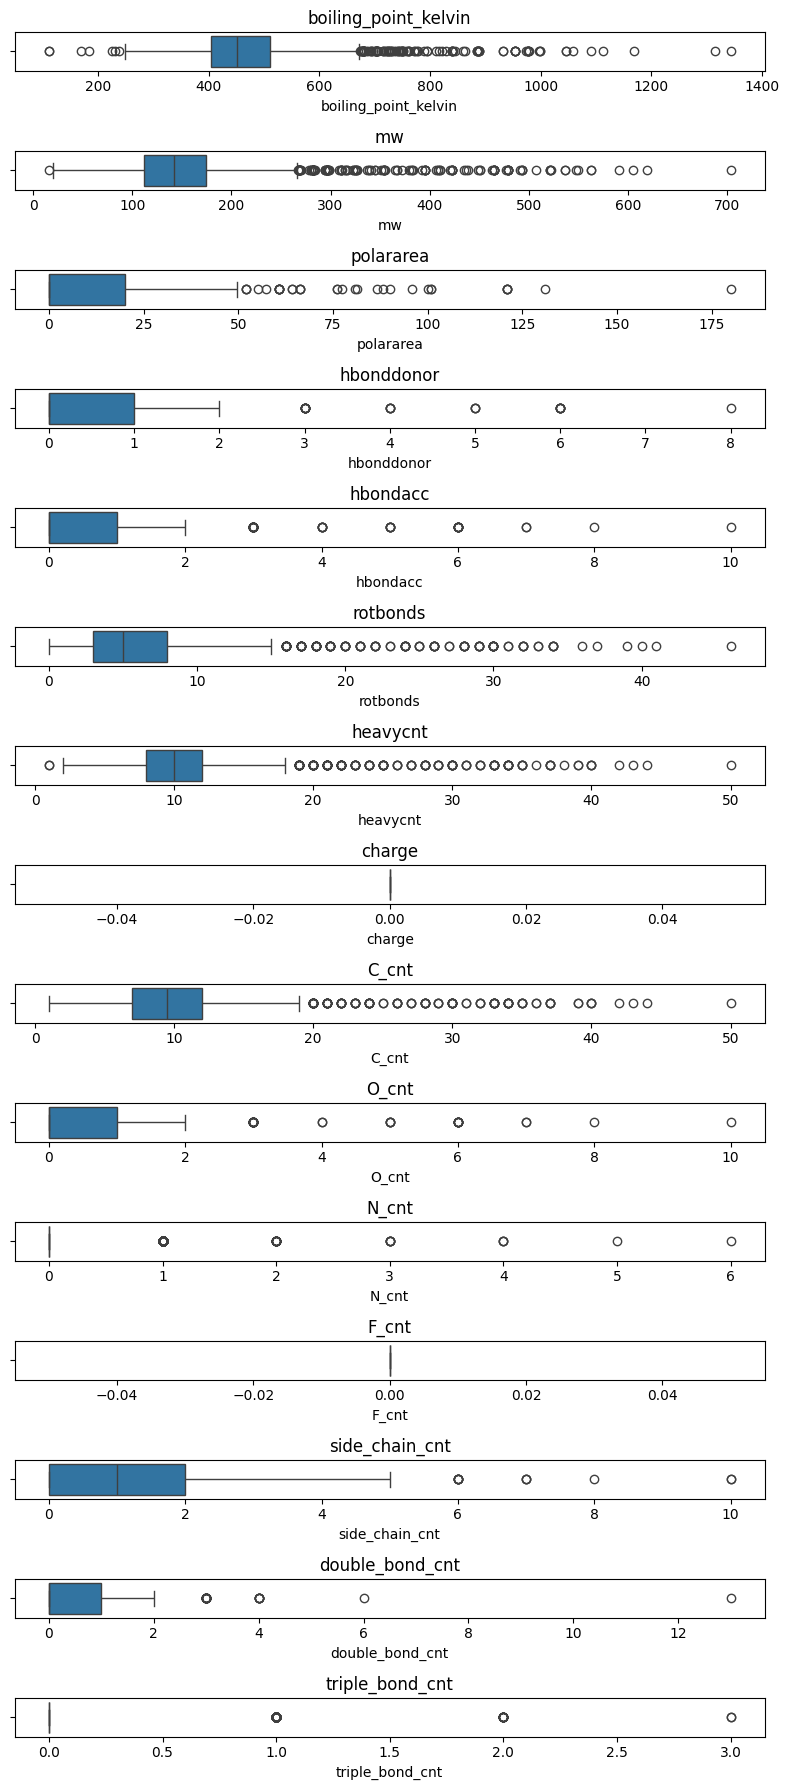

In [11]:
# Check outliers

# Select only numeric columns for plotting
numeric_df = df.select_dtypes(include='number')
fig, axes = plt.subplots(nrows=len(numeric_df.columns), figsize=(8, len(df.columns)*1))

for i, col in enumerate(numeric_df.columns):
    sns.boxplot(x=numeric_df[col], ax=axes[i], orient='h')
    axes[i].set_title(col)

plt.tight_layout()
plt.show()


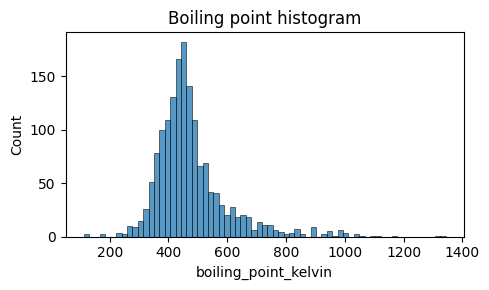

In [12]:
fig = viz.plot_boiling_point_histogram(df)
fig.savefig("results/images/boiling_point_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


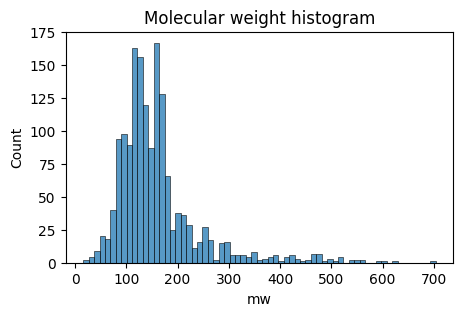

In [13]:
plt.figure(figsize=(5,3))
sns.histplot(df['mw'])
plt.title('Molecular weight histogram')
plt.show()


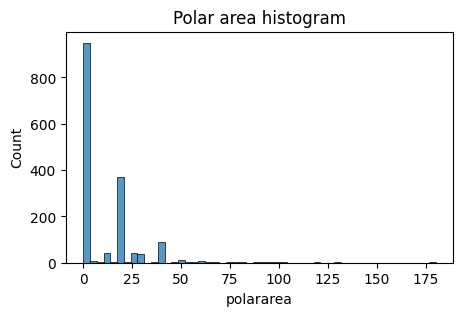

In [14]:
plt.figure(figsize=(5,3))
sns.histplot(df['polararea'])
plt.title('Polar area histogram')
plt.show()


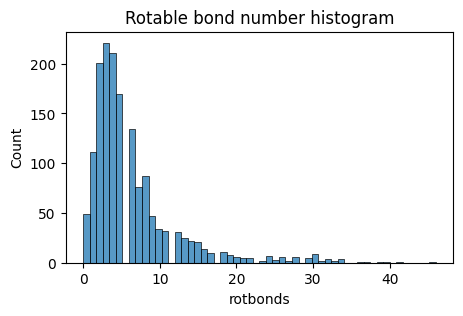

In [15]:
plt.figure(figsize=(5,3))
sns.histplot(df['rotbonds'])
plt.title('Rotable bond number histogram')
plt.show()


* There are outliers in the data, particularly there is a small amount of data with high molecular weight or polar area or rotable bond number. Those data are real though rare.
* We will not remove those outliers as we want our model to predict for those cases too.

In [16]:
# Get correlation matrix to help determine most correlated variables
df.corr(numeric_only=True)


,boiling_point_kelvin,mw,polararea,hbonddonor,hbondacc,rotbonds,heavycnt,charge,C_cnt,O_cnt,N_cnt,F_cnt,side_chain_cnt,double_bond_cnt,triple_bond_cnt
boiling_point_kelvin,1.000000,0.896967,0.241092,0.229715,0.233364,0.858528,0.890193,NaN,0.835444,0.264343,-0.040444,NaN,0.052948,-0.107336,-0.093213
mw,0.896967,1.000000,-0.058511,-0.079914,-0.024446,0.972335,0.999402,NaN,0.982917,-0.015383,-0.020619,NaN,0.011180,-0.093989,-0.108088
polararea,0.241092,-0.058511,1.000000,0.968981,0.953218,-0.061547,-0.083576,NaN,-0.231747,0.877727,0.242792,NaN,0.072172,-0.173303,-0.082285
hbonddonor,0.229715,-0.079914,0.968981,1.000000,0.884672,-0.085193,-0.103175,NaN,-0.240155,0.798616,0.257631,NaN,0.088499,-0.166299,-0.076451
hbondacc,0.233364,-0.024446,0.953218,0.884672,1.000000,-0.022667,-0.050350,NaN,-0.206566,0.883944,0.329144,NaN,0.045577,-0.182983,-0.090876
rotbonds,0.858528,0.972335,-0.061547,-0.085193,-0.022667,1.000000,0.971250,NaN,0.955022,-0.032103,0.016908,NaN,-0.191885,-0.113336,-0.119909
heavycnt,0.890193,0.999402,-0.083576,-0.103175,-0.050350,0.971250,1.000000,NaN,0.987575,-0.039813,-0.026050,NaN,0.004445,-0.073713,-0.092790
charge,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
C_cnt,0.835444,0.982917,-0.231747,-0.240155,-0.206566,0.955022,0.987575,NaN,1.000000,-0.178003,-0.077258,NaN,-0.002881,-0.043297,-0.076521
O_cnt,0.264343,-0.015383,0.877727,0.798616,0.883944,-0.032103,-0.039813,NaN,-0.178003,1.000000,-0.150594,NaN,0.092673,-0.134670,-0.062858


In [17]:
df = features.drop_uninformative_columns(df) # Drop 'charge' and 'F_cnt' column as there is no correlation at all
df


,cmpdname,boiling_point_kelvin,mw,mf,polararea,hbonddonor,hbondacc,rotbonds,heavycnt,isosmiles,C_cnt,O_cnt,N_cnt,side_chain_cnt,double_bond_cnt,triple_bond_cnt
0,Ethylene Glycol,470.65,62.070,C2H6O2,40.5,2,2,1,4,C(CO)O,2,2,0,1,0,0
1,"2,3-Butanediol",455.15,90.120,C4H10O2,40.5,2,2,1,6,CC(C(C)O)O,4,2,0,2,0,0
2,1-Butanol,390.75,74.120,C4H10O,20.2,1,1,2,5,CCCCO,4,1,0,0,0,0
3,Methane,111.65,16.043,CH4,0.0,0,0,0,1,C,1,0,0,0,0,0
4,Octane,398.77,114.230,C8H18,0.0,0,0,5,8,CCCCCCCC,8,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1583,"3,5-Dimethyl-2,4-heptadiene",413.15,124.220,C9H16,0.0,0,0,2,9,CC/C(=C/C(=C/C)/C)/C,9,0,0,2,2,0
1584,"2,2,4,4-Tetramethyl-3-hexanol",460.65,158.280,C10H22O,20.2,1,1,3,11,CCC(C)(C)[C@@H](C(C)(C)C)O,10,1,0,5,0,0
1585,"3,3-Dimethyl-2-ethyl-1-butanol",471.15,130.229,C8H18O,20.2,1,1,3,9,CC[C@@H](CO)C(C)(C)C,8,1,0,3,0,0
1586,"3,3,4-Trimethyl-2-pentanol",437.90,130.229,C8H18O,20.2,1,1,2,9,C[C@@H](C(C)(C)C(C)C)O,8,1,0,4,0,0


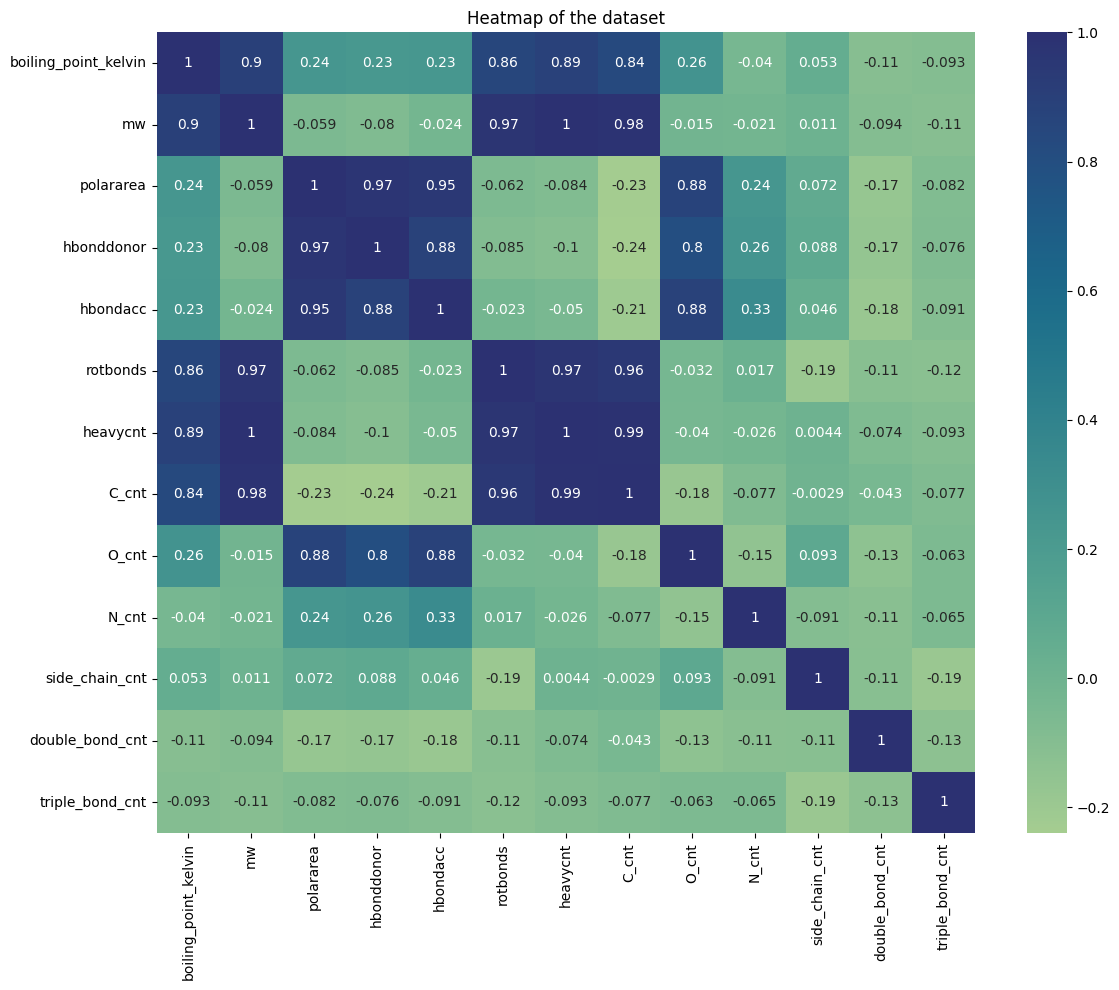

In [18]:
fig = viz.plot_correlation_heatmap(df)
fig.savefig("results/images/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


  *   Variables that are correlated with boiling points are: "mw"	"polararea", "heavycnt", "rotbonds", "C_cnt", 'O_cnt', "hbonddonor",	"hbondacc". However, it is noted that some of those variables are (closely) correlated, like ["mw", "heavycnt", "C_cunt", and "rotbonds"],  ["hbonddonor" and "hbondacc"]. It is not necessary to choose all of them if we need to mannually select features for models selected; tree-based models will selct features intrinsically.
  *   These make sense as the major factors affecting boiling points theretically include: molecular weight (Van Der Waals force), ploarity and O_cnt (hydrogen bonding, dipole-dipole attraction ), ionic bonding (charge 0 here, so not a factor for our data)

# Model construction
 * Approach
 1. Split the data into training/validation/test.
 2. Cross-validate/tune hyperparameters on the training dataset with GridSearchCV for each chosen ML architecyutre.
 3. Compare the tuned model of each different architecture on the validation dataset and select the ‘champion’ ML architecture.
 4. Retrain the champion model using training dataset + validation dataset, and further use that model to predict (check model performance on test dataset and predict unknown boiling points)

 *  Five ML architectures are tested ,including
 1. Linear regression
 2. Random forest
 3. XGBoost
 4. Neural network
 5. Support Vector Regressionk


## Prepare the dataset for model training

In [19]:
#Show column names
df.columns


Index(['cmpdname', 'boiling_point_kelvin', 'mw', 'mf', 'polararea',
       'hbonddonor', 'hbondacc', 'rotbonds', 'heavycnt', 'isosmiles', 'C_cnt',
       'O_cnt', 'N_cnt', 'side_chain_cnt', 'double_bond_cnt',
       'triple_bond_cnt'],
      dtype='object')

In [20]:
# Define the X (predictor) and y (target) variables
X = features.select_model_features(df)
y = features.get_target(df)

# Split into train/val/test (60/20/20)
X_train, X_val, X_test, y_train, y_val, y_test = preprocessing.train_val_test_split(X, y, random_state=42)

# Get shape of each training, validation, and testing set
X_train.shape, X_val.shape, X_test.shape, y_train.shape, y_val.shape, y_test.shape


((952, 12), (318, 12), (318, 12), (952,), (318,), (318,))

In [21]:
# X_train.describe()


## Linear regression model

In [22]:
# Normalise the data
# Normalised data will be used for linear regression model and later for neural network model
X_train_scaled, X_val_scaled, X_test_scaled, scaler_X = preprocessing.scale_features(X_train, X_val, X_test)
y_train_scaled, y_val_scaled, y_test_scaled, scaler_y = preprocessing.scale_target(y_train, y_val, y_test)


In [23]:
start_time = time.time()
lr_cv = models.train_ridge_cv(X_train_scaled, y_train_scaled)
end_time = time.time()
print(f"Time taken for Grid Search training: {end_time - start_time:.2f} seconds")
print()

best_ridge = lr_cv.best_estimator_
print("Best alpha:", lr_cv.best_params_)
print("Coefficients:", best_ridge.coef_)
print("Intercept:", best_ridge.intercept_)


Time taken for Grid Search training: 0.01 seconds

Best alpha: {'alpha': 0.1}
Coefficients: [ 0.4417069  -0.02561774  0.39071091  0.01186223 -0.46095558  0.47287322
  0.47497381  0.04683786 -0.0672971  -0.08105726  0.00096665 -0.00921201]
Intercept: 3.9277148291657284e-16


In [24]:
lr_rmse_unscaled = models.rmse_from_cv_scaled(lr_cv, y_train)
print(f'RMSE on the unscaled data: {lr_rmse_unscaled:.4f}')


RMSE on the unscaled data: 37.1035


## Random forest model

In [25]:
# Here I use the unscaled data for tree-based models
start_time = time.time()
rf_cv = models.train_random_forest_cv(X_train, y_train)
end_time = time.time()
print(f"Time taken for Grid Search training: {end_time - start_time:.2f} seconds")
print()


Time taken for Grid Search training: 22.71 seconds



In [26]:
rf_rmse = models.rmse_from_cv_unscaled(rf_cv)
print(f'RMSE on the unscaled data: {rf_rmse:.4f}')


RMSE on the unscaled data: 39.4987


In [27]:
# Examine best parameters
rf_cv.best_params_


{'max_depth': 10,
 'max_features': 0.6,
 'max_samples': 0.9,
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 200}

## XGBoost model

In [28]:
xgb_cv = models.train_xgboost_cv(X_train, y_train)


In [29]:
xgb_rmse = models.rmse_from_cv_unscaled(xgb_cv)
print(f'RMSE on the unscaled data: {xgb_rmse:.4f}')


RMSE on the unscaled data: 35.7267


In [30]:
xgb_cv.best_params_


{'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 5,
 'n_estimators': 300}

## Neural Network model

In [31]:
nn_cv = models.train_mlp_cv(X_train_scaled, y_train_scaled)
best_nn = nn_cv.best_estimator_


In [32]:
nn_rmse_unscaled = models.rmse_from_cv_scaled(nn_cv, y_train)
print(f'RMSE on the unscaled data: {nn_rmse_unscaled:.4f}')


RMSE on the unscaled data: 29.5403


In [33]:
# Examine best parameters
nn_cv.best_params_


{'activation': 'relu',
 'alpha': 0.01,
 'hidden_layer_sizes': (100, 50, 20),
 'learning_rate': 'constant',
 'learning_rate_init': 0.001,
 'solver': 'adam'}

## Support Vector Regression

In [34]:
svr_cv = models.train_svr_cv(X_train_scaled, y_train_scaled)


In [35]:
svr_rmse_unscaled = models.rmse_from_cv_scaled(svr_cv, y_train)
print(f'RMSE on the unscaled data: {svr_rmse_unscaled:.4f}')


RMSE on the unscaled data: 38.3631


In [36]:
# Examine best parameters
svr_cv.best_params_


{'C': 10, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}

In [37]:
# Summarise the results from different models
results={'Liner Regression':lr_rmse_unscaled, 'Ramdom Forest':rf_rmse,'XGBoost':xgb_rmse, 'Neural Network':nn_rmse_unscaled,'Support Vector Regression':svr_rmse_unscaled}
TrainError = pd.DataFrame(list(results.items()), columns=['Model', 'RMSE_Train'])
TrainError


,Model,RMSE_Train
0,Liner Regression,37.103513
1,Ramdom Forest,39.498656
2,XGBoost,35.726731
3,Neural Network,29.540280
4,Support Vector Regression,38.363099


## Evaluate the models

In [38]:
# Evaluate the models on the validation set

# linear regression "best estimator" model
y_pred_lr_scaled = lr_cv.best_estimator_.predict(X_val_scaled)
y_pred_lr = scaler_y.inverse_transform(y_pred_lr_scaled.reshape(-1, 1)).flatten()

# Random forest "best estimator" model
y_pred_rf = rf_cv.best_estimator_.predict(X_val)

# XGBoost model "best estimator" model
y_pred_xgb = xgb_cv.best_estimator_.predict(X_val)

# Neural network "best estimator" model
y_pred_nn_scaled = nn_cv.best_estimator_.predict(X_val_scaled)
y_pred_nn = scaler_y.inverse_transform(y_pred_nn_scaled.reshape(-1, 1)).flatten()

# Support vector regression "best estimator" model
y_pred_svr_scaled = svr_cv.best_estimator_.predict(X_val_scaled)
y_pred_svr = scaler_y.inverse_transform(y_pred_svr_scaled.reshape(-1, 1)).flatten()

# Calculate Root Mean Squared Error
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
rmse_nn = np.sqrt(mean_squared_error(y_val, y_pred_nn))
rmse_svr = np.sqrt(mean_squared_error(y_val, y_pred_svr))

# Calculate R^2 (proportion of variance in the target explained by the model)
r2_lr = r2_score(y_val, y_pred_lr)
r2_rf = r2_score(y_val, y_pred_rf)
r2_xgb = r2_score(y_val, y_pred_xgb)
r2_nn = r2_score(y_val, y_pred_nn)
r2_svr = r2_score(y_val, y_pred_svr)

results={'Model':['Liner Regression', 'Ramdom Forest','XGBoost', 'Neural Network','Support Vector Regression'],'RMSE_Validate':[rmse_lr,rmse_rf,rmse_xgb,rmse_nn,rmse_svr]}
ValidationError=pd.DataFrame(results)
Error=pd.merge(TrainError,ValidationError, on='Model')
Error


,Model,RMSE_Train,RMSE_Validate
0,Liner Regression,37.103513,47.944774
1,Ramdom Forest,39.498656,52.504831
2,XGBoost,35.726731,48.961606
3,Neural Network,29.540280,45.268499
4,Support Vector Regression,38.363099,51.072420


 * The Validation errors are higher than the training errors, indicating overfitting problems for all the models, and particularly overfitting is serious for Neural Network model and the Support Vector Regaression.
 * XGBoost model performs best in general with a low training error and relatively lower variance/overfitting.
 * When using a different train/validate/test split (random_state=1 instead of 42), the valiation errors became lower than training errors, indicating the split of of data affect the result since our dataset is not large (the training dataset might happen to contain more 'easy' cases, while the validation dataset contain more 'hard' cases). 
 * Whether XGBoost's edge here is a real, reliable difference or just this particular split's luck is checked formally in the next section (Split Sensitivity Check) before committing to a final modeling approach.

## Split Sensitivity Check

The validation comparison above is based on a single train/val split, and the
hyperparameter tuning (`GridSearchCV`) only cross-validates *within* the
training set — the comparison *across* architectures is still a single draw.
Given the modest dataset size (1,588 compounds), that one draw can be
unrepresentative.

To check how much this matters, each architecture's already-tuned
hyperparameters (found above) are refit — with no re-tuning — across several
different train/val splits, and the validation RMSE is recorded each time.
Comparing the resulting mean ± std per architecture (rather than one number)
shows whether the ranking above is a real difference or just split noise.

In [39]:
tuned_estimators = {
    "Ridge": lr_cv.best_estimator_,
    "Random Forest": rf_cv.best_estimator_,
    "XGBoost": xgb_cv.best_estimator_,
    "Neural Network": nn_cv.best_estimator_,
    "SVR": svr_cv.best_estimator_,
}

sensitivity_results = evaluation.repeated_split_comparison(
    X, y, tuned_estimators, seeds=range(10)
)
evaluation.summarize(sensitivity_results)

,mean,std
model,,
Neural Network,34.72,3.60
SVR,36.95,4.84
Random Forest,37.78,4.48
XGBoost,37.96,3.07
Ridge,38.17,3.92


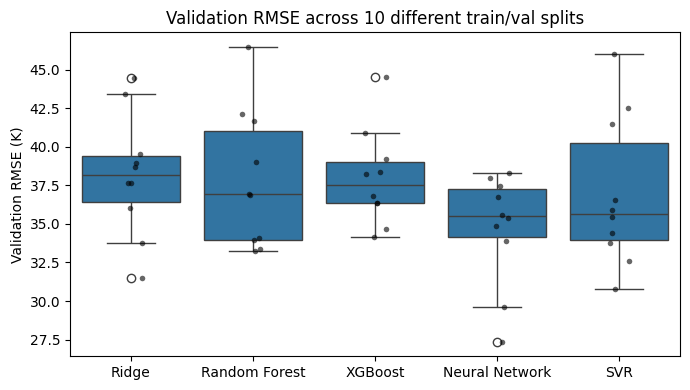

In [40]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=sensitivity_results, x="model", y="rmse")
sns.stripplot(data=sensitivity_results, x="model", y="rmse", color="black", size=4, alpha=0.6)
plt.title("Validation RMSE across 10 different train/val splits")
plt.ylabel("Validation RMSE (K)")
plt.xlabel("")
plt.tight_layout()
plt.savefig("results/images/split_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

* The mean ± std validation RMSE ranges overlap substantially across all five
architectures (Neural Network 34.7±3.6 through Ridge 38.2±3.9) — none of these
differences are large relative to the spread. On a dataset this size (1,588
compounds), the single-split "XGBoost wins" result from the comparison above
is not a statistically reliable conclusion; it's largely a product of which
rows happened to land in the validation set for that particular split.
* Since no single architecture is reliably better, picking one "champion" is
partly arbitrary. Instead, going forward this notebook uses a simple-averaging
**ensemble of Ridge, XGBoost, and the Neural Network** — one representative of
each genuinely different inductive bias (linear/regularized, tree/boosting,
nonlinear), which is what makes averaging useful rather than just noise.
Random Forest is left out as redundant with XGBoost (same tree-based family,
and XGBoost had the edge in most single-split comparisons above); SVR is left
out for being the least stable across splits (highest variance here, ±6.6 vs
±3.3-5.3 for the others) despite a competitive mean.

# Build the Ensemble


In [41]:
# Re-tune each ensemble member on the training + validation data together
# (mirrors the rigor previously applied only to XGBoost's retrain step --
# hyperparameters found on X_train alone aren't necessarily optimal for the
# larger combined set)
X_train_val = pd.concat([X_train, X_val])
y_train_val = pd.concat([y_train, y_val])

lr_cv_final, xgb_cv_final, nn_cv_final = models.retrain_ensemble_members(X_train_val, y_train_val)

ensemble = ensemble_module.AverageEnsembleRegressor(
    ridge=lr_cv_final.best_estimator_,
    xgb=xgb_cv_final.best_estimator_,
    nn=nn_cv_final.best_estimator_,
)
ensemble.fit(X_train_val, y_train_val)


AverageEnsembleRegressor(nn=MLPRegressor(hidden_layer_sizes=(100, 50, 20),
                                         max_iter=1000, random_state=0),
                         ridge=Ridge(alpha=0.1),
                         xgb=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=0.1, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=3,
                                          max_leaves=None, min_child_weight=3,
                                          missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=300,
                                          n_jobs=None, num_parallel_tree=None,
                                          random_state=0, ...))

In [42]:
# Hyperparameters used by each ensemble member, re-tuned on train+val
{"Ridge": lr_cv_final.best_params_, "XGBoost": xgb_cv_final.best_params_, "Neural Network": nn_cv_final.best_params_}


{'Ridge': {'alpha': 0.1},
 'XGBoost': {'learning_rate': 0.1,
  'max_depth': 3,
  'min_child_weight': 3,
  'n_estimators': 300},
 'Neural Network': {'activation': 'relu',
  'alpha': 0.0001,
  'hidden_layer_sizes': (100, 50, 20),
  'learning_rate': 'constant',
  'learning_rate_init': 0.001,
  'solver': 'adam'}}

In [43]:
cv_scores = cross_val_score(ensemble, X_train_val, y_train_val, cv=5, scoring="neg_mean_squared_error")
ensemble_cv_rmse = np.sqrt(-cv_scores.mean())
print(f'Ensemble 5-fold CV RMSE on train+val: {ensemble_cv_rmse:.4f}')


Ensemble 5-fold CV RMSE on train+val: 35.7200


# Use the Ensemble to Predict on Test Data


In [44]:
# Use the ensemble to predict on test data
test_metrics = models.evaluate_on_test(ensemble, X_test, y_test)
y_pred = ensemble.predict(X_test)

print(f"Ensemble RMSE on test dataset: {test_metrics['rmse']:.4f}")
print(f"Ensemble MAE on test dataset: {test_metrics['mae']:.4f}")
print(f"Ensemble R^2 Score on test dataset: {test_metrics['r2']:.4f}")


Ensemble RMSE on test dataset: 26.2402
Ensemble MAE on test dataset: 15.1843
Ensemble R^2 Score on test dataset: 0.9461


* The ensemble's test RMSE (26.24 K) is lower than its 5-fold CV RMSE on train+val (35.72 K), the same 'easy test set' pattern seen throughout this project — likely due to which compounds happened to land in the test set on a dataset this size, not a sign the ensemble generalizes better than the CV estimate suggests.


In [45]:
print(y_pred.shape)
y_pred[:5]


(318,)


array([626.39133912, 366.77974223, 451.39989795, 328.23442746,
       360.08618448])

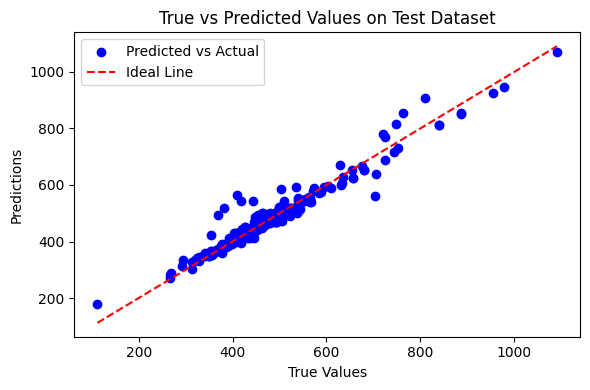

In [46]:
fig = viz.plot_predicted_vs_actual(y_test, y_pred)
fig.savefig("results/images/predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()


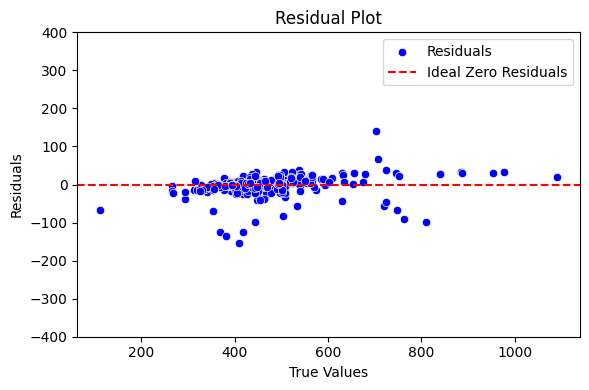

In [47]:
# Calculate residuals (errors)
residuals = y_test - y_pred
fig = viz.plot_residuals(y_test, residuals)
fig.savefig("results/images/residual_plot.png", dpi=150, bbox_inches="tight")
plt.show()


## Error Analysis

In [48]:
large_residual_index=residuals[(residuals<-100) | (residuals>100)].index
df.iloc[large_residual_index]


,cmpdname,boiling_point_kelvin,mw,mf,polararea,hbonddonor,hbondacc,rotbonds,heavycnt,isosmiles,C_cnt,O_cnt,N_cnt,side_chain_cnt,double_bond_cnt,triple_bond_cnt
660,N-Methyldioctylamine,410.15,255.50,C17H37N,3.2,0,1,14,18,CCCCCCCCN(C)CCCCCCCC,17,0,1,1,0,0
611,"1,8-Octanediol",418.15,146.23,C8H18O2,40.5,2,2,7,10,C(CCCCO)CCCO,8,2,0,1,0,0
538,"2,6-Nonadien-1-ol",369.65,140.22,C9H16O,20.2,1,1,5,10,CC/C=C/CC/C=C/CO,9,1,0,0,2,0
578,Pentaethylene glycol,702.44,238.28,C10H22O6,77.4,2,6,13,16,C(COCCOCCOCCOCCO)O,10,6,0,1,0,0
680,N-Methyldodecylamine,382.15,199.38,C13H29N,12.0,1,1,11,14,CCCCCCCCCCCCNC,13,0,1,0,0,0


* Among the predictions with large errors, we can see the chemicals have large polar area and/or rotbonds. Those chemicals are 'outliers' of our dataset. To improve the model accuracy, we should collect more data, particularly more data with large polar area and/or rotbonds to re-train the model.

## Feature Importance (XGBoost Ensemble Member)


mw                 0.539286
O_cnt              0.183983
hbonddonor         0.072476
polararea          0.070679
side_chain_cnt     0.038456
rotbonds           0.027767
heavycnt           0.021579
C_cnt              0.019299
N_cnt              0.011084
double_bond_cnt    0.007541
triple_bond_cnt    0.004247
hbondacc           0.003604
dtype: float32
0.9326467


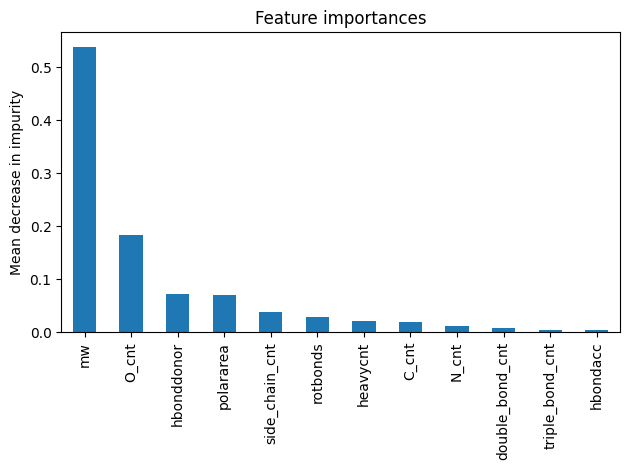

In [49]:
importances = ensemble.xgb_.feature_importances_
xgb_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

fig = viz.plot_feature_importance(importances, X.columns)
fig.savefig("results/images/feature_importance.png", dpi=150, bbox_inches="tight")
print(xgb_importances)
print(np.sum(xgb_importances[:6]))


<Figure size 3000x2000 with 0 Axes>

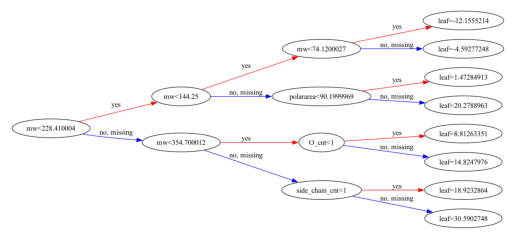

In [50]:
# Plot the tree
# Retrieve the best model (booster)
booster = ensemble.xgb_.get_booster()

# Plot the first tree from the model
plt.figure(figsize=(30, 20))
xgb.plot_tree(booster, num_trees=4, rankdir='LR')  # Change num_trees for other trees
plt.show()


 * It is shown that the major important features are: mv (molecular weight), O_cnt(count of O atom), hbonddonor(Hydrogen Bond Donor Count), polararea, side_chain_cnt (count of side-chains), rotbonds(rotable bonds number).

## Learning Curve: How Much Would More Data Help?

The split-sensitivity check above shows the current 1,588-compound dataset is
too small to reliably distinguish between architectures. A direct way to ask
"would more data help, and how much" is a learning curve: train the ensemble
on increasingly large subsets of the training data and track validation
RMSE at each size. If the validation curve is still dropping steeply at the
current data size, collecting more data should meaningfully improve accuracy.
If it has flattened out, more data of the *same kind* would yield diminishing
returns, and effort would be better spent elsewhere (e.g. better features,
or more data specifically for underrepresented regions like the high
polar-area/rotatable-bond outliers noted in the error analysis).

In [51]:
train_sizes_frac = np.linspace(0.1, 1.0, 10)
train_sizes_abs, lc_train_scores, lc_val_scores = learning_curve(
    ensemble,
    X_train_val, y_train_val,
    train_sizes=train_sizes_frac,
    cv=5,
    scoring="neg_mean_squared_error",
    shuffle=True,
    random_state=42,
)
lc_train_rmse = np.sqrt(-lc_train_scores)
lc_val_rmse = np.sqrt(-lc_val_scores)

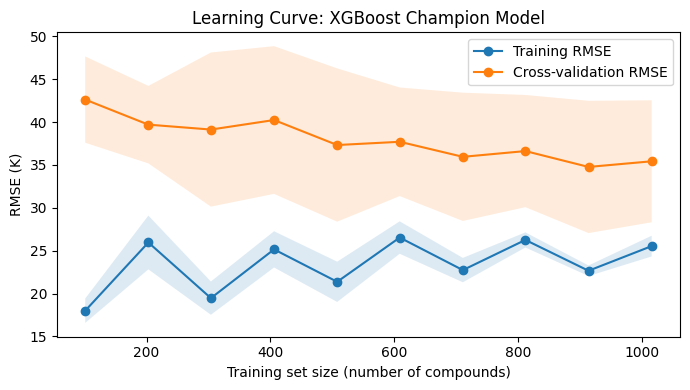

,train_size,train_rmse,cv_rmse,cv_rmse_std
0,101,18.01,42.63,5.03
1,203,25.96,39.70,4.52
2,304,19.47,39.13,8.99
3,406,25.16,40.25,8.61
4,508,21.38,37.33,8.94
5,609,26.54,37.71,6.33
6,711,22.74,35.95,7.48
7,812,26.26,36.62,6.54
8,914,22.67,34.77,7.71
9,1016,25.54,35.43,7.11


In [52]:
plt.figure(figsize=(7, 4))
plt.plot(train_sizes_abs, lc_train_rmse.mean(axis=1), "o-", label="Training RMSE")
plt.fill_between(train_sizes_abs, lc_train_rmse.mean(axis=1) - lc_train_rmse.std(axis=1),
                  lc_train_rmse.mean(axis=1) + lc_train_rmse.std(axis=1), alpha=0.15)
plt.plot(train_sizes_abs, lc_val_rmse.mean(axis=1), "o-", label="Cross-validation RMSE")
plt.fill_between(train_sizes_abs, lc_val_rmse.mean(axis=1) - lc_val_rmse.std(axis=1),
                  lc_val_rmse.mean(axis=1) + lc_val_rmse.std(axis=1), alpha=0.15)
plt.xlabel("Training set size (number of compounds)")
plt.ylabel("RMSE (K)")
plt.title("Learning Curve: XGBoost Champion Model")
plt.legend()
plt.tight_layout()
plt.savefig("results/images/learning_curve.png", dpi=150, bbox_inches="tight")
plt.show()

pd.DataFrame({
    "train_size": train_sizes_abs,
    "train_rmse": lc_train_rmse.mean(axis=1).round(2),
    "cv_rmse": lc_val_rmse.mean(axis=1).round(2),
    "cv_rmse_std": lc_val_rmse.std(axis=1).round(2),
})

* The overall trend is still declining (CV RMSE 42.63 K at the smallest
training size down to 34.77-35.43 K at the largest), indicating the
ensemble is still data-limited rather than having reached its accuracy
ceiling for this feature set, so collecting more data should continue to
help. The curve is fairly noisy and not strictly monotonic (e.g. it rises
from 34.77 K back up to 35.43 K at the very last point) — likely because
it's averaging three architectures with different sample-size
sensitivities (Ridge, XGBoost, and the Neural Network don't necessarily
respond to more data at the same rate), which makes point-to-point
movements less reliable to read than the broad trend across the full
range.
* This points to the same practical takeaway found elsewhere in this
notebook: meaningful gains would need substantially more data than a few
hundred rows, not that more data wouldn't help at all.


## Alternative Split Ratio: 70/20/10 (Train/Val/Test)

The main pipeline above uses a 60/20/20 split. Following on from the
train:val vs. test tradeoff discussed above, this section re-runs the full
comparison (all 5 architectures, same `GridSearchCV` tuning procedure) with
a 70/20/10 split instead — giving each model 16% more training data, at
the cost of a smaller, noisier 159-compound test set (vs. 318 previously) for
the final read on generalization.

In [53]:
X_train_c, X_val_c, X_test_c, y_train_c, y_val_c, y_test_c = preprocessing.train_val_test_split(
    X, y, test_size=0.1, val_size=0.2 / 0.9, random_state=42
)
print(f"train={len(X_train_c)} ({len(X_train_c)/len(X):.1%}), "
      f"val={len(X_val_c)} ({len(X_val_c)/len(X):.1%}), "
      f"test={len(X_test_c)} ({len(X_test_c)/len(X):.1%})")

X_train_c_scaled, X_val_c_scaled, X_test_c_scaled, scaler_X_c = preprocessing.scale_features(
    X_train_c, X_val_c, X_test_c
)
y_train_c_scaled, y_val_c_scaled, y_test_c_scaled, scaler_y_c = preprocessing.scale_target(
    y_train_c, y_val_c, y_test_c
)

lr_cv_c = models.train_ridge_cv(X_train_c_scaled, y_train_c_scaled)
rf_cv_c = models.train_random_forest_cv(X_train_c, y_train_c)
xgb_cv_c = models.train_xgboost_cv(X_train_c, y_train_c)
nn_cv_c = models.train_mlp_cv(X_train_c_scaled, y_train_c_scaled)
svr_cv_c = models.train_svr_cv(X_train_c_scaled, y_train_c_scaled)

tuned_estimators_c = {
    "Ridge": lr_cv_c.best_estimator_,
    "Random Forest": rf_cv_c.best_estimator_,
    "XGBoost": xgb_cv_c.best_estimator_,
    "Neural Network": nn_cv_c.best_estimator_,
    "SVR": svr_cv_c.best_estimator_,
}

train=1111 (70.0%), val=318 (20.0%), test=159 (10.0%)


In [54]:
train_rmse_c = {
    "Ridge": models.rmse_from_cv_scaled(lr_cv_c, y_train_c),
    "Random Forest": models.rmse_from_cv_unscaled(rf_cv_c),
    "XGBoost": models.rmse_from_cv_unscaled(xgb_cv_c),
    "Neural Network": models.rmse_from_cv_scaled(nn_cv_c, y_train_c),
    "SVR": models.rmse_from_cv_scaled(svr_cv_c, y_train_c),
}

val_rmse_c = evaluation.evaluate_tuned_models(
    tuned_estimators_c, X_val_c, X_val_c_scaled, y_val_c, scaler_y_c
)

comparison_70_20_10 = pd.DataFrame({"model": list(train_rmse_c.keys()),
                                     "train_rmse": list(train_rmse_c.values())}).set_index("model")
comparison_70_20_10 = comparison_70_20_10.join(val_rmse_c.rename(columns={"rmse": "val_rmse"}))
comparison_70_20_10.round(2)

,train_rmse,val_rmse
model,,
Ridge,41.02,31.21
Random Forest,41.45,32.65
XGBoost,38.68,32.55
Neural Network,35.52,30.09
SVR,42.39,29.95


In [55]:
# Re-tune each ensemble member on the 70/20/10 split's train+val, then
# evaluate on the held-out 10% test set
X_train_val_c = pd.concat([X_train_c, X_val_c])
y_train_val_c = pd.concat([y_train_c, y_val_c])
lr_cv_c_final, xgb_cv_c_final, nn_cv_c_final = models.retrain_ensemble_members(X_train_val_c, y_train_val_c)

ensemble_c = ensemble_module.AverageEnsembleRegressor(
    ridge=lr_cv_c_final.best_estimator_,
    xgb=xgb_cv_c_final.best_estimator_,
    nn=nn_cv_c_final.best_estimator_,
)
ensemble_c.fit(X_train_val_c, y_train_val_c)

test_metrics_70_20_10 = models.evaluate_on_test(ensemble_c, X_test_c, y_test_c)
test_metrics_60_20_20 = models.evaluate_on_test(ensemble, X_test, y_test)

pd.DataFrame({
    "60/20/20 (baseline)": test_metrics_60_20_20,
    "70/20/10": test_metrics_70_20_10,
}).round(4)


,60/20/20 (baseline),70/20/10
rmse,26.2402,27.9225
mae,15.1843,16.1589
r2,0.9461,0.9312


* The ensemble's test performance got *worse* with 70/20/10 (RMSE 26.24
→ 27.92 K, R² 0.946 → 0.931), despite 16% more training data. This is
consistent with, not contradictory to, the rest of this notebook: the
70/20/10 test set is much smaller (159 vs 318 compounds), and the
split-sensitivity check earlier already showed RMSE swings of this size
are well within normal split-to-split noise at this dataset size, for
every architecture tested.
* Practical takeaway: a single before/after comparison on a shrunk test
set isn't reliable evidence either way about whether more training data
helped or hurt — it mainly demonstrates, again, how much split-luck
dominates evaluation on a dataset this small.


## Extending the Dataset: Targeted NIST WebBook Collection

The error analysis above flags compounds with high polar area and/or
rotatable bonds as underrepresented and disproportionately responsible for
the largest prediction errors, and the learning curve shows the model is
still data-limited. `scripts/scrape_nist_boiling_points.py` targets exactly
that region on the [NIST Chemistry WebBook](https://webbook.nist.gov/chemistry/) —
checking 5,400 PubChem candidates not already in the literature dataset for
high polar area (≥40) and/or rotatable bonds (≥14), with a name filter
biased toward compounds NIST's curated database is likely to cover (see
`nist_scraper.select_targeted_candidates`). That run found boiling point
data for **105 compounds (a 1.94% hit rate)** — confirming, as suspected,
that this outlier region is itself underrepresented in NIST's coverage, not
just in the original literature dataset.

This section adds those 105 compounds to the dataset and re-runs the full
pipeline (same architectures, same tuning procedure, same 60/20/20 split
ratio and random_state) to see whether it helped, rather than just
replacing the original results — the comparison against the original run is
the point.

In [56]:
# Rebuild the merged, feature-engineered dataset with the NIST additions
df_nist = data.load_nist_data("compound_boiling_points_from_nist.csv")
df1_aug = pd.concat([df1, df_nist], ignore_index=True)
print(f"literature: {len(df1)}, NIST additions: {len(df_nist)}, combined: {len(df1_aug)}")

df_aug = data.merge_datasets(df1_aug, df2)
df_aug = features.add_smiles_features(df_aug)
df_aug = features.drop_uninformative_columns(df_aug)
print(f"merged + feature-engineered: {df_aug.shape[0]} compounds (vs {df.shape[0]} originally)")

literature: 1748, NIST additions: 105, combined: 1853
merged + feature-engineered: 1693 compounds (vs 1588 originally)


In [57]:
X_aug = features.select_model_features(df_aug)
y_aug = features.get_target(df_aug)

X_train_aug, X_val_aug, X_test_aug, y_train_aug, y_val_aug, y_test_aug = preprocessing.train_val_test_split(
    X_aug, y_aug
)
X_train_aug_scaled, X_val_aug_scaled, X_test_aug_scaled, scaler_X_aug = preprocessing.scale_features(
    X_train_aug, X_val_aug, X_test_aug
)
y_train_aug_scaled, y_val_aug_scaled, y_test_aug_scaled, scaler_y_aug = preprocessing.scale_target(
    y_train_aug, y_val_aug, y_test_aug
)

lr_cv_aug = models.train_ridge_cv(X_train_aug_scaled, y_train_aug_scaled)
rf_cv_aug = models.train_random_forest_cv(X_train_aug, y_train_aug)
xgb_cv_aug = models.train_xgboost_cv(X_train_aug, y_train_aug)
nn_cv_aug = models.train_mlp_cv(X_train_aug_scaled, y_train_aug_scaled)
svr_cv_aug = models.train_svr_cv(X_train_aug_scaled, y_train_aug_scaled)

tuned_estimators_aug = {
    "Ridge": lr_cv_aug.best_estimator_,
    "Random Forest": rf_cv_aug.best_estimator_,
    "XGBoost": xgb_cv_aug.best_estimator_,
    "Neural Network": nn_cv_aug.best_estimator_,
    "SVR": svr_cv_aug.best_estimator_,
}

In [58]:
train_rmse_aug = {
    "Ridge": models.rmse_from_cv_scaled(lr_cv_aug, y_train_aug),
    "Random Forest": models.rmse_from_cv_unscaled(rf_cv_aug),
    "XGBoost": models.rmse_from_cv_unscaled(xgb_cv_aug),
    "Neural Network": models.rmse_from_cv_scaled(nn_cv_aug, y_train_aug),
    "SVR": models.rmse_from_cv_scaled(svr_cv_aug, y_train_aug),
}
val_rmse_aug = evaluation.evaluate_tuned_models(
    tuned_estimators_aug, X_val_aug, X_val_aug_scaled, y_val_aug, scaler_y_aug
)

gap_comparison = pd.DataFrame({"model": list(train_rmse_aug.keys()),
                                "train_rmse": list(train_rmse_aug.values())}).set_index("model")
gap_comparison = gap_comparison.join(val_rmse_aug.rename(columns={"rmse": "val_rmse"}))
gap_comparison["val_minus_train"] = gap_comparison["val_rmse"] - gap_comparison["train_rmse"]
gap_comparison.round(2)

,train_rmse,val_rmse,val_minus_train
model,,,
Ridge,42.18,40.30,-1.89
Random Forest,42.92,43.51,0.59
XGBoost,37.84,41.77,3.93
Neural Network,33.98,41.52,7.55
SVR,36.47,49.88,13.41


In [59]:
# Re-tune each ensemble member on the augmented dataset's train+val, then
# evaluate on the same-ratio held-out test set
X_train_val_aug = pd.concat([X_train_aug, X_val_aug])
y_train_val_aug = pd.concat([y_train_aug, y_val_aug])
lr_cv_aug_final, xgb_cv_aug_final, nn_cv_aug_final = models.retrain_ensemble_members(X_train_val_aug, y_train_val_aug)

ensemble_aug = ensemble_module.AverageEnsembleRegressor(
    ridge=lr_cv_aug_final.best_estimator_,
    xgb=xgb_cv_aug_final.best_estimator_,
    nn=nn_cv_aug_final.best_estimator_,
)
ensemble_aug.fit(X_train_val_aug, y_train_val_aug)

test_metrics_aug = models.evaluate_on_test(ensemble_aug, X_test_aug, y_test_aug)
test_metrics_original = models.evaluate_on_test(ensemble, X_test, y_test)

pd.DataFrame({
    "Original (1,588 compounds)": test_metrics_original,
    "NIST-extended (1,693 compounds)": test_metrics_aug,
}).round(4)


,"Original (1,588 compounds)","NIST-extended (1,693 compounds)"
rmse,26.2402,25.9275
mae,15.1843,15.2410
r2,0.9461,0.9470


* **Test performance improved slightly**: RMSE dropped from 26.24 K to
25.93 K and R² rose marginally (0.9461 → 0.9470); MAE ticked up slightly
(15.18 → 15.24 K). This is a modest, mixed improvement — plausible given
the ensemble's baseline RMSE is already fairly low, leaving limited
headroom, and averaging across three architectures can dilute the effect
of an improvement concentrated in just one of them.
* **The train/validation gap shrank substantially for most individual
architectures** (see `val_minus_train` above) — dramatically for Ridge and
Random Forest, meaningfully for XGBoost and the Neural Network. SVR didn't
benefit. This is a direct, same-split variance-reduction signal, and it's
a property of the added data, not of which combination of models is used
downstream.
* **This one targeted round wasn't enough to fully close the gap it was
aimed at**: newly-added NIST compounds with the same high-rotatable-bond
profile the scrape targeted (e.g. long unbranched alkanes/alkenes) still
show up among the largest-residual predictions in the error analysis even
after being added to the training data. A 1.94% hit rate against 5,400
candidates yielding 105 compounds is a real but modest addition (+6.6% to
the dataset) — consistent with the learning curve's message that this
region needs meaningfully more data than one scraping pass can practically
provide, not that the approach doesn't work.


# Conclusions
 1. Five classic ML models, including Linear Regression, Random Forest, XGBoost, Neural Network, and Support Vector Regression are evaluated for the problem of predicting chemical compounds boiling points on a total dataset of 1588 entries. Sensitivity of the model performance on train/validate/test data split was found thus it is recommaned to collect more data as a follow-up. Since no single architecture was reliably better than the others, a simple-averaging ensemble of Ridge, XGBoost, and Neural Network is used instead of a single champion model.
 2. Feature selection is naturally embedded with the training process of the XGBoost component of the ensemble. The model shows that major important features affecting boiling points for our dataset (all compouonds have no charge) are: mv (molecular weight), O_cnt(count of O atom), hbonddonor(Hydrogen Bond Donor Count), polararea, side_chain_cnt (count of side-chains), rotbonds(rotable bonds number).
 3. To further improve the model performance, collect more data (particularly more data with large polar area and/or rotbonds) to re-train the model.